## Objetivo del análisis exploratorio

Antes de construir cualquier modelo predictivo, se necesita entender a fondo los datos con los que se trabaja. Este análisis exploratorio tiene tres propósitos principales:

1. **Conocer la estructura del dataset**: cuántos registros tenemos, qué variables existen, de qué tipo son y si hay datos faltantes.
2. **Identificar qué variables realmente distinguen a los clientes que se van de los que se quedan**: no todas las variables aportan información útil individualmente para predecir el churn.
3. **Tomar decisiones informadas sobre qué conservar, qué descartar y qué transformar** antes de construir el modelo.

El dataset contiene información de clientes de una empresa de telecomunicaciones. La variable que queremos predecir es **Churn**, que indica si un cliente canceló su contrato (Yes) o lo mantiene activo (No).


La primera sección cubre todo lo necesario para conocer el dataset antes de hacer cualquier análisis. En concreto:

- **Estructura general**: cuántos clientes y variables tenemos, y qué tipo de dato representa cada columna.
- **Calidad de los datos**: si hay valores faltantes que puedan causar errores más adelante.
- **Clasificación de variables**: separamos las variables en tres grupos — categóricas (texto/categorías), numéricas (valores continuos) y binarias (solo dos valores posibles). Esta clasificación ayuda para definir qué tipo de transformación necesitará cada una dentro del pipeline.
- **Estadísticas descriptivas**: para las variables numéricas, revisamos rango, media y dispersión. Esto ayuda a detectar escalas muy distintas entre variables, lo cual afecta al modelo si no se normaliza.
- **Distribución del target**: ¿qué proporción de clientes hizo churn? Esto es clave porque si el dataset está muy desbalanceado, el modelo puede aprender a predecir siempre la clase mayoritaria y aún así tener una precisión aparentemente alta.
- **Tasa de churn por categoría binaria**: un primer vistazo textual a cómo varía el churn según la variable SeniorCitizen que aunque está codificada como número, representa una categoría binaria (mayor o menor de 65 años).


In [10]:
#Librerias utilizadas en el análisis exploratorio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr

### 1) Entendimiento inicial de los datos

In [5]:
df = pd.read_csv('../data/02_Base_Customer-Churn.csv', sep=";")

print("\nDIMENSIONES DEL DATASET")
print("--------------------------")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")


DIMENSIONES DEL DATASET
--------------------------
Filas: 7043
Columnas: 21


In [ ]:
print("\nPRIMERAS FILAS DEL DATASET")
print("--------------------------")
pd.set_option('display.max_columns', None)
df.head(12)

In [ ]:
print("\nINFO DEL DATASET")
print("-------------------")

df.info()

In [ ]:
print("\nVALORES NULOS POR COLUMNA")
print("--------------------------")
for col in df.columns:
    print(f"{col}: {df[col].isnull().sum()}")

In [ ]:
# Identificación de columnas categóricas y numéricas 
# (excluyendo el ID y la variable objetivo)

categorical_cols = df.drop(["customerID", "Churn"], axis=1).select_dtypes(include="object").columns
numerical_cols = df.drop(["SeniorCitizen"], axis=1).select_dtypes(exclude="object").columns 
binary_cols = ["SeniorCitizen"]

# Normalización de categorías para columnas con "No internet service" o "No phone service" 
# por "No" para simplificar el análisis de churn por categoría 
# ya que estas categorías representan la ausencia de un servicio y no una categoría distinta.

cols_normalizar = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in cols_normalizar:
    
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

print("\nCOLUMNAS CATEGÓRICAS")
print("-------------------")
for col in categorical_cols:
    print(col)

print("\nCOLUMNAS NUMÉRICAS")
print("-------------------")
for col in numerical_cols:
    print(col)

In [ ]:
print("\nESTADÍSTICAS DESCRIPTIVAS")
print("----------------------------")
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df[num_cols].describe().round(2).T

In [254]:
#Tasa de Churn global
df["Churn"].value_counts(normalize=True).round(3) * 100

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64

In [ ]:
#Funcion para calcular la tasa de churn por categoría
#esto nos ayudará a identificar qué categorías son más propensas a la deserción.

def churn_rate_by_category(df, col): 
    return (
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean().round(3) * 100) # Calcular tasa de churn en porcentaje
        .sort_values(ascending=False) # Ordenar de mayor a menor
        .reset_index(name='churn_rate') 
    )


In [256]:
print("Proporción de clientes mayores de 65 años \n(0 = No - 1 = Si)" )
print("---------------------------------")
print(df["SeniorCitizen"].value_counts(normalize=True).round(3) * 100)

print("\nTasa de churn por SeniorCitizen")
print("---------------------------------")

for col in binary_cols:
    print(churn_rate_by_category(df, col))


Proporción de clientes mayores de 65 años 
(0 = No - 1 = Si)
---------------------------------
SeniorCitizen
0    83.8
1    16.2
Name: proportion, dtype: float64

Tasa de churn por SeniorCitizen
---------------------------------
   SeniorCitizen  churn_rate
0              1        41.7
1              0        23.6


Estructura y calidad:
El dataset tiene **7.043 clientes** y **21 variables**. Se detectaron **11 valores nulos** únicamente en TotalCharges — un número pequeño pero suficiente para que el modelo falle si no se trata.

Clasificación de variables:
Las variables se agruparon en tres tipos que determinan cómo serán analizadas más adelante:
- Categóricas (texto): gender, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, `OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod.

- Numéricas: tenure, MonthlyCharges, TotalCharges.

- Binaria codificada como número: SeniorCitizen (0 = menor de 65 años, 1 = mayor). Se trata por separado para no confundirla con una variable númerica.

Distribución del target:
Aproximadamente el **26.5% de los clientes hizo churn** y el **73.5% se mantuvo activo**. El dataset está moderadamente desbalanceado: hay casi tres veces más clientes que no se van que los que sí lo hacen.



### 2) Análisis univariado — variables categóricas

Las variables categóricas describen características del cliente y los servicios contratados: tipo de contrato, método de pago, si tiene internet, soporte técnico, etc.

Para saber si alguna de estas variables es útil para predecir el churn, calculamos la **tasa de churn por cada categoría**: del total de clientes en cada grupo, ¿qué porcentaje se fue? 

Si las tasas son muy similares entre categorías, la variable no aporta información diferenciadora por si sola. Si hay diferencias grandes, la variable tiene poder predictivo.

La línea punteada gris en cada gráfico representa la tasa global de churn (26.5%) y sirve de referencia para ver qué categorías están por encima o por debajo del promedio.


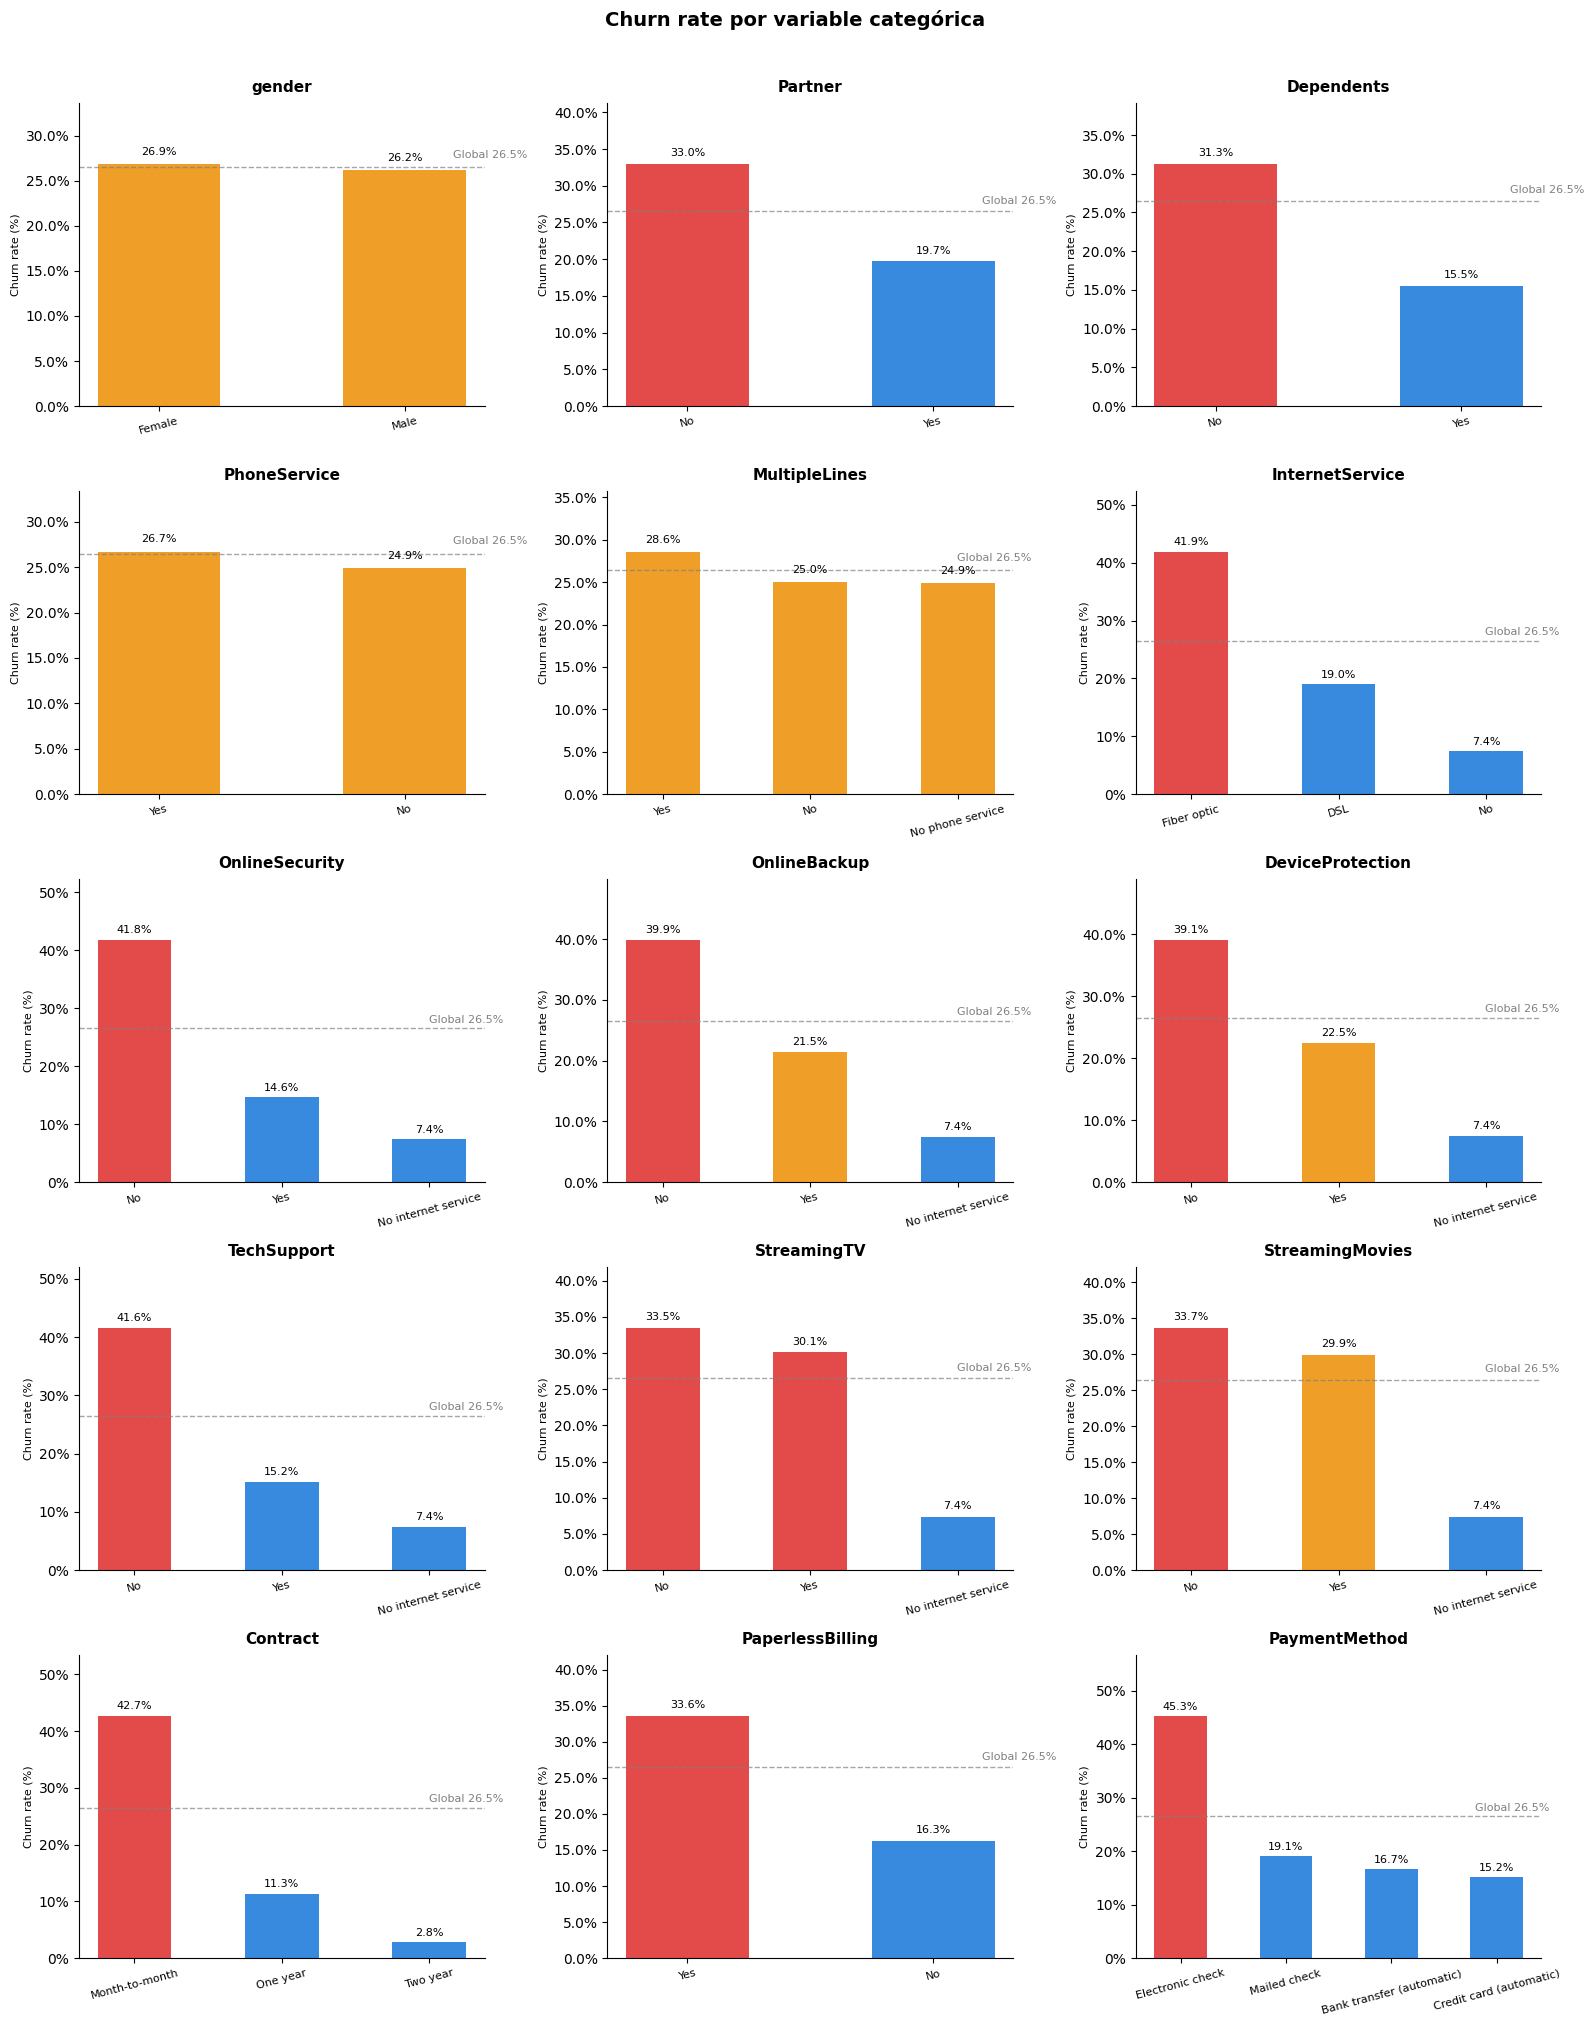

Referencia: rojo > 30% | amarillo 20–30% | azul < 20%


In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten() 

for i, col in enumerate(categorical_cols):
    
    churn_rate = churn_rate_by_category(df, col)

    bars = axes[i].bar(
        churn_rate[col], churn_rate['churn_rate'],
        color=['#E24B4A' if v > 30 else '#378ADD' if v < 20 else '#EF9F27'
               for v in churn_rate['churn_rate']],
        edgecolor='none', width=0.5
    )

    # Línea de referencia: tasa global de churn
    axes[i].axhline(26.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    axes[i].text(len(churn_rate) - 0.5, 27.5, 'Global 26.5%',
                 fontsize=8, color='gray', ha='right')

    # Etiquetas de valor sobre cada barra
    for bar, val in zip(bars, churn_rate['churn_rate']):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.8,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

    axes[i].set_title(col, fontsize=11, fontweight='bold', pad=8)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Churn rate (%)', fontsize=8)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].set_ylim(0, max(churn_rate['churn_rate']) * 1.25)
    axes[i].tick_params(axis='x', labelsize=8, rotation=15)
    axes[i].spines[['top', 'right']].set_visible(False)

plt.suptitle('Churn rate por variable categórica', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

plt.show()

print("Referencia: rojo > 30% | amarillo 20–30% | azul < 20%")

Los resultados muestran diferencias muy marcadas en varias variables:

- **Contract** es la más poderosa: los clientes con contrato mes a mes tienen una tasa de churn del **42.7%**, mientras que los de dos años apenas alcanzan el **2.8%**. A mayor compromiso contractual, menor abandono.
- **InternetService**: los clientes con fibra óptica presentan un churn del **41.9%**, muy por encima de los de DSL (19%) o sin internet (7.4%).
- **OnlineSecurity** y **TechSupport**: los clientes sin estos servicios tienen el doble de churn que los que sí los tienen. Tener estos servicios activos parece anclar al cliente.
- **PaymentMethod**: los clientes que pagan con cheque electrónico tienen un churn del **45.3%**, notablemente más alto que los métodos automáticos (=15%).
- Variables como **gender** y **PhoneService** muestran tasas casi idénticas entre categorías, lo que confirma que no aportan información útil de manera individual.


### 3) Fuerza de asociación

Los gráficos anteriores proporcionan una intuición visual, pero se necesita una medida objetiva que cuantifique cuán fuerte es la relación entre cada variable categórica y el churn. Para eso se optó por utilizar el método estadístico de **V de Cramér**.

El V de Cramér retorna un número entre 0 y 1: cuanto más cercano a 1, más fuertemente asociada está la variable con el churn. Los umbrales de referencia que usamos son:
- **Mayor a 0.30** → asociación alta
- **Entre 0.15 y 0.30** → asociación media
- **Menor a 0.15** → asociación baja o nula

Esto nos permite ordenar todas las variables por su capacidad real de diferenciar entre clientes que hacen churn y los que no.


In [258]:
def cramers_v(x, y):
    """Calcula el V de Crámer entre dos variables categóricas."""
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

# Calcular para todas las variables categóricas vs Churn
resultados = {}
for col in categorical_cols:
    resultados[col] = cramers_v(df[col].astype(str), df['Churn'])

cramer_df = (pd.DataFrame.from_dict(resultados, orient='index', columns=['Cramer_V'])
             .sort_values('Cramer_V', ascending=False)
             .round(4))


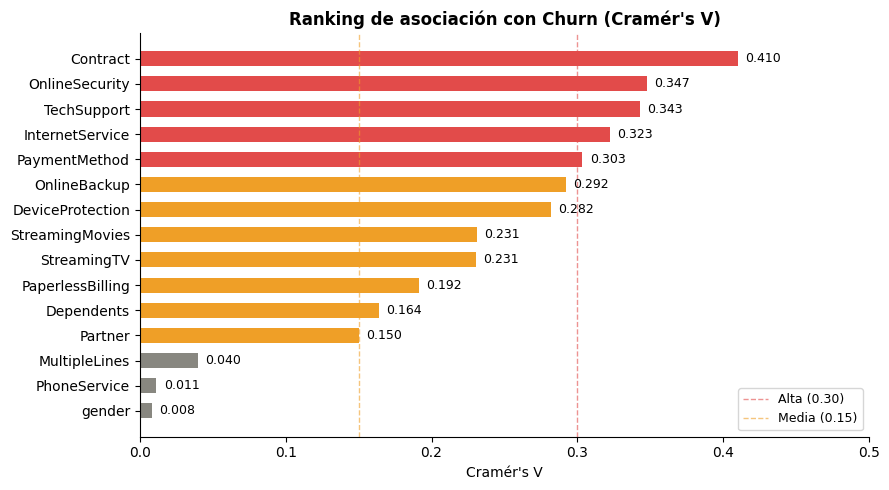

In [ ]:
# Visualización del ranking de Cramér's V
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#E24B4A' if v > 0.30 else '#EF9F27' if v >= 0.15 else '#888780'
          for v in cramer_df['Cramer_V']]

bars = ax.barh(cramer_df.index[::-1], cramer_df['Cramer_V'][::-1],
               color=colors[::-1], edgecolor='none', height=0.6)

# Etiquetas de valor
for bar, val in zip(bars, cramer_df['Cramer_V'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

# Líneas de referencia
ax.axvline(0.30, color='#E24B4A', linestyle='--', linewidth=1, alpha=0.6, label='Alta (0.30)')
ax.axvline(0.15, color='#EF9F27', linestyle='--', linewidth=1, alpha=0.6, label='Media (0.15)')

ax.set_xlabel("Cramér's V", fontsize=10)
ax.set_title("Ranking de asociación con Churn (Cramér's V)", fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 0.50)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

plt.show()


El ranking confirma y precisa lo que se aprecia visualmente:

- **Contract (V=0.41)** es la variable categórica más predictiva del dataset.
- **OnlineSecurity (0.35)**, **TechSupport (0.34)** e **InternetService (0.32)** forman un segundo grupo de alta relevancia.
- **PaymentMethod (0.30)** está justo en el umbral de alta asociación.
- **StreamingTV (0.23)**, **PaperlessBilling (0.19)**, **Dependents (0.16)** y **Partner (0.15)** tienen asociación media — aportan señal, aunque moderada.
- **MultipleLines (0.04)**, **PhoneService (0.01)** y **gender (0.008)** tienen valores prácticamente nulos. Estas tres variables son candidatas a descartar, quizás incluirlas en el modelo solo añadiría ruido sin aportar capacidad predictiva.


### 4) Análisis univariado — variables numéricas

A diferencia de las variables categóricas, las variables numéricas no se comparan por grupos fijos, ya que toman muchos valores posibles. Por eso, para analizar si tenure (antigüedad del cliente) y MonthlyCharges (cargo mensual) ayudan a distinguir entre clientes que hacen churn y los que no, se comparan sus distribuciones en cada grupo.

Para esto se utilizaron histogramas superpuestos, que permiten ver si los valores de una variable se comportan de forma diferente entre clientes con churn y sin churn. Si las distribuciones son distintas, la variable puede ser útil para predecir el abandono.


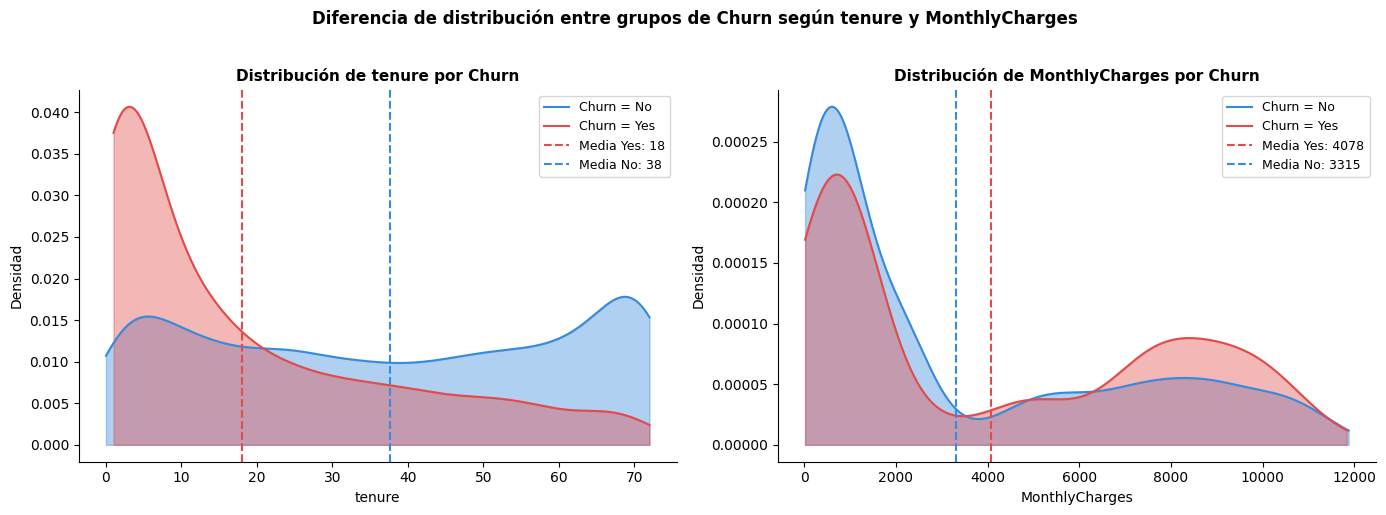

In [12]:
num_cols_finales = ['tenure', 'MonthlyCharges']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(num_cols_finales):
    churn_yes = df[df['Churn'] == 'Yes'][col]
    churn_no  = df[df['Churn'] == 'No'][col]

    for data, color, label in [
        (churn_no,  '#378ADD', 'Churn = No'),
        (churn_yes, '#E24B4A', 'Churn = Yes'),
    ]:
        kde = gaussian_kde(data)
        x = np.linspace(data.min(), data.max(), 300)
        y = kde(x)
        axes[i].plot(x, y, color=color, linewidth=1.5, label=label)
        axes[i].fill_between(x, y, alpha=0.4, color=color)

    # medias
    axes[i].axvline(churn_yes.mean(), color='#E24B4A', linestyle='--', linewidth=1.5,
                    label=f'Media Yes: {churn_yes.mean():.0f}')
    axes[i].axvline(churn_no.mean(),  color='#378ADD', linestyle='--', linewidth=1.5,
                    label=f'Media No: {churn_no.mean():.0f}')

    axes[i].set_title(f'Distribución de {col} por Churn', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Densidad', fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].spines[['top', 'right']].set_visible(False)

plt.suptitle('Diferencia de distribución entre grupos de Churn según tenure y MonthlyCharges',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**tenure (antigüedad del cliente):**
Las distribuciones son claramente distintas entre grupos. Los clientes que hicieron churn tienen una antigüedad media de aproximadamente **18 meses**, mientras que los que se quedan promedian **38 meses**. Esto confirma que los clientes nuevos son mucho más propensos a abandonar — el primer año es el período más crítico.

**MonthlyCharges (cargo mensual):**
Los clientes que hacen churn tienden a pagar más por mes. Esto está relacionado con que los planes de fibra óptica, que tienen mayor churn, también son más caros. La diferencia entre grupos existe, aunque es menos pronunciada que en tenure.



### 5) Redundancia y correlación entre variables numéricas

Si dos variables contienen esencialmente la misma información, incluir ambas en el modelo quizás no mejora la predicción — puede que solo agregue ruido y provocar **multicolinealidad**, un problema técnico que afecta la estabilidad del modelo.

En esta sección medimos:
1. **Correlación de Pearson de variables independientes con target**: qué tan fuertemente se relaciona cada variable numérica con el churn.
2. **Correlación de Pearson entre numéricas**: si las variables numéricas se mueven juntas y por lo tanto contienen información redundante.


In [260]:
print("Correlación de Pearson vs Churn")
print("-" * 45)
print(f"{'Variable':<20} {'r':>5}  {'Señal':>15}")
print("-" * 45)

# Imputar los 11 nulos con la mediana
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Variable binaria temporal para Churn (1 = Yes, 0 = No)
churn_bin = (df['Churn'] == 'Yes').astype(int)

# Matriz de correlación
corr = pd.concat([
    churn_bin.rename('Churn_bin'),
    df[['tenure', 'MonthlyCharges', 'TotalCharges']]
], axis=1).corr()

for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    
    r = corr.loc[col, 'Churn_bin']
    
    señal = (
        'alta' if abs(r) > 0.25
        else 'media' if abs(r) > 0.10
        else 'baja'
    )
    
    print(f"{col:<20} {r:>8.2f}  {señal:>12}")

Correlación de Pearson vs Churn
---------------------------------------------
Variable                 r            Señal
---------------------------------------------
tenure                  -0.35          alta
MonthlyCharges           0.09          baja
TotalCharges            -0.12         media


In [ ]:
#Acá lo que busco es identificar si hay alguna discrepancia 
# entre el valor real de TotalCharges y el valor esperado aproximado calculado como tenure * MonthlyCharges,
# ya que esto podría indicar errores en los datos o casos atípicos que podrían influir en el churn.

# Valor esperado aproximado
expected_total = df['tenure'] * df['MonthlyCharges']

# Diferencia entre valor real y esperado
diff_charges = df['TotalCharges'] - expected_total

# Resumen de discrepancias
print(diff_charges.describe().round(2).to_frame().T)

# Correlación con churn
r = diff_charges.corr(churn_bin)

print("\nCorrelación diff_charges vs Churn")
print(f"r = {r:.4f}")


    count     mean        std       min     25%  50%     75%       max
0  7043.0  2168.87  207926.66 -819955.0 -8742.0  0.0  9849.5  810281.0

Correlación diff_charges vs Churn
r = -0.0030


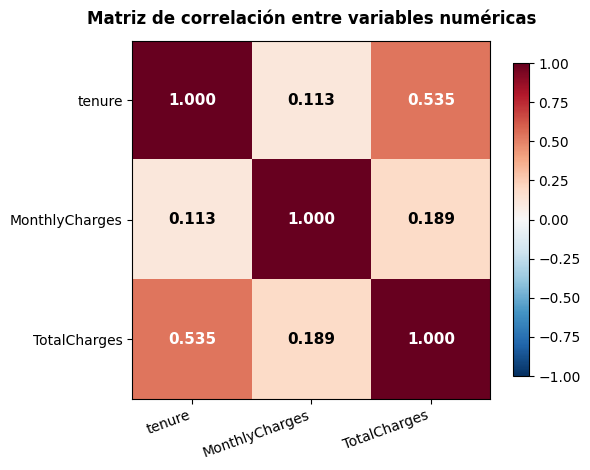

Nota: Se propone descartar TotalCharges por alta correlación con tenure (r=0.53)
Esto indica multicolinealidad y además tiene 11 valores nulos.


In [14]:
# Matriz de correlación entre variables numéricas originales
num_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df[num_vars].corr().round(3)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(num_vars)))
ax.set_yticks(range(len(num_vars)))
ax.set_xticklabels(num_vars, rotation=20, ha='right', fontsize=10)
ax.set_yticklabels(num_vars, fontsize=10)

for i in range(len(num_vars)):
    for j in range(len(num_vars)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=11, color=color, fontweight='bold')

ax.set_title('Matriz de correlación entre variables numéricas', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()

plt.show()


print("Nota: Se propone descartar TotalCharges por alta correlación con tenure (r=0.53)")
print("Esto indica multicolinealidad y además tiene 11 valores nulos.")


- **tenure** tiene la correlación más fuerte con churn (r = -0.35): el signo negativo confirma que a mayor antigüedad, menor probabilidad de churn. Es la variable numérica más informativa del conjunto.

- Aunque **TotalCharges** mantiene una correlación moderada con tenure (r = 0.53), se observaron diferencias relevantes entre el valor registrado y el valor esperado aproximado calculado como tenure × MonthlyCharges. Para explorar estas diferencias, se construyó la variable derivada **diff_charges**, correspondiente a la diferencia entre ambos valores.

- El análisis descriptivo de diff_charges mostró una alta dispersión entre los registros. Sin embargo, su correlación con churn fue prácticamente nula (r = -0.003), indicando ausencia de valor predictivo adicional.

- Debido a esto, TotalCharges se considera una variable parcialmente redundante respecto a tenure, aportando una señal limitada y poco diferenciada para el problema de churn. Por simplicidad e interpretabilidad del modelo, se propone descartarla.

- **MonthlyCharges** presenta una correlación positiva baja con churn (r = 0.09). Aunque su señal es débil, aporta información complementaria distinta a tenure, por lo que se propone conservarla.

La matriz de correlación confirma visualmente que tenure y TotalCharges son las variables numéricas más relacionadas entre sí, respaldando la decisión de simplificar el conjunto de variables manteniendo únicamente aquellas con señal más interpretable y diferenciada.

### Resumen y propuesta inicial

Con base en el análisis exploratorio (Cramér V, correlaciones, distribución por churn y redundancia entre variables), se propone un conjunto final de variables orientado a capturar patrones de comportamiento del cliente, reduciendo redundancia e incrementando la interpretabilidad del modelo.

Se define un conjunto de 12 variables base junto con 3 variables derivadas mediante feature engineering, totalizando 15 variables conceptuales que serán transformadas dentro del pipeline de modelado.

**Propuesta de variables a descartar:**

- customerID: identificador sin valor predictivo.

- gender y PhoneService: presentan una asociación prácticamente nula con churn (Cramér V < 0.02), por lo que no aportan señal relevante para el modelo.

- MultipleLines: presenta baja capacidad discriminativa (Cramér V = 0.0398), lo que sugiere una contribución individual marginal al problema de predicción.

- TotalCharges: aunque teóricamente relacionado con tenure y MonthlyCharges, presenta variabilidad no completamente explicada por estas variables. Se evaluó una variable derivada (diff_charges), la cual no mostró relación significativa con churn (r = -0.003). En este contexto, se decide no incluirla en el modelo base.

- OnlineBackup, DeviceProtection, TechSupport y OnlineSecurity: estas variables tienen la posibilidad de no ser utilizadas de forma individual, ya que su información se consolida en la variable agregada n_servicios_proteccion, que captura el nivel de adopción de servicios de protección del cliente.

- StreamingMovies: Puede no ser utiliza de forma individual, ya que su información se permite integrar en la variable agregada n_servicios_streaming, debido a su comportamiento altamente similar con StreamingTV.

**Features nuevas potenciales:**

- n_servicios_proteccion: variable construida como el conteo de servicios de seguridad y soporte contratados por el cliente (OnlineSecurity, TechSupport, OnlineBackup y DeviceProtection). Esta feature resume el nivel de uso de servicios de valor agregado y presenta una relación decreciente consistente con churn, donde los clientes con menor cantidad de servicios tienden a presentar mayor probabilidad de abandono.

- n_servicios_streaming: variable que agrupa el consumo de servicios de entretenimiento digital (StreamingTV y StreamingMovies). Permite capturar el nivel de uso de servicios de entretenimiento como una sola dimensión de comportamiento del cliente.

- contrato_pago_riesgo: variable de interacción entre tipo de contrato y método de pago. Este segmento agrupa perfiles de alto riesgo (especialmente contratos mes a mes combinados con pago por cheque electrónico), los cuales presentan tasas de churn significativamente superiores al promedio del dataset.

**Siguiente paso**

Con este análisis, se procede a la construcción del pipeline de preprocesamiento, incluyendo codificación de variables categóricas, escalado de variables numéricas, generación de features derivadas y validación del impacto de las variables mediante el modelo supervisado.